In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df=pd.read_csv("8-fraud_detection.csv")


In [2]:
df.columns

Index(['transaction_amount', 'transaction_risk_score', 'is_fraud'], dtype='object')

In [3]:
df.head()

,transaction_amount,transaction_risk_score,is_fraud
0,1.879910,-1.485035,0
1,0.377083,-2.238585,0
2,1.354312,-2.664638,0
3,-0.509843,-1.502950,0
4,0.863561,-1.906364,0


In [4]:
df["is_fraud"].value_counts()

is_fraud
0    9846
1     154
Name: count, dtype: int64

In [5]:
#imbalanced dataset 


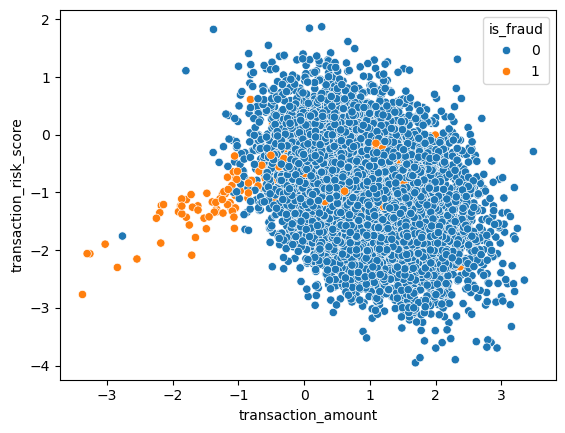

In [8]:
X=df.drop("is_fraud",axis=1)
y=df["is_fraud"]
sns.scatterplot(x=X["transaction_amount"],y=X["transaction_risk_score"],hue=y)
plt.show()


In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15)
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()
penalty=["l1","l2","elasticnet"]
c=[0.01,0.1,1,10,100]
solver=["newton-cg","lbfgs","liblinear","sag","saga","newton-cholesky"]
class_weight=[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]
class_weight




[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [18]:
params=dict(penalty=penalty,C=c,solver=solver,class_weight=class_weight)
from sklearn.model_selection import GridSearchCV,StratifiedKFold
cv=StratifiedKFold()
grid_search=GridSearchCV(estimator=log_model,param_grid=params,cv=cv,n_jobs=-1,scoring="accuracy")
import warnings
warnings.filterwarnings("ignore")

In [19]:
grid_search.fit(X_train,y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 1, 1: 50}, {0: 1, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 10},
                                          {0: 10, 1: 50}, {0: 10, 1: 100},
                                          {0: 50, 1: 1}, {0: 50, 1: 10},
                                          {0: 50, 1: 50}, {0: 50, 1: 100},
                                          {0: 100, 1: 1}, {0: 100, 1: 10},
                                          {0: 100, 1: 50}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga', 'newton-cholesky']},
             scoring='accuracy')

In [20]:
y_pred=grid_search.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [21]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print("accuracy score:",accuracy_score(y_test,y_pred))
print("classification report:\n",classification_report(y_test,y_pred))
print("confusion matrix:\n",confusion_matrix(y_test,y_pred))

accuracy score: 0.99
classification report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      2462
           1       0.84      0.42      0.56        38

    accuracy                           0.99      2500
   macro avg       0.92      0.71      0.78      2500
weighted avg       0.99      0.99      0.99      2500

confusion matrix:
 [[2459    3]
 [  22   16]]


In [22]:
grid_search.best_params_

{'C': 0.01,
 'class_weight': {0: 10, 1: 50},
 'penalty': 'l2',
 'solver': 'newton-cg'}

In [23]:
# roc auc 
#nedir bunlar 
# imbalanced datasetlerde accuracy score yanıltıcı olabilir. Bu yüzden roc auc score kullanılır.
# ROC: eşik değeri değiştirildiğinde modelin performansını gösteren bir grafik. 
# AUC: ROC eğrisinin altında kalan alan. AUC değeri 0.5 ile 1 arasında değişir. 0.5 değeri rastgele tahmin anlamına gelirken, 1 değeri mükemmel bir model anlamına gelir. İdeal olarak, AUC değeri 0.7 veya daha yüksek olmalıdır.

grid_search.predict_proba(X_test)


array([[0.99586436, 0.00413564],
       [0.85287009, 0.14712991],
       [0.952308  , 0.047692  ],
       ...,
       [0.98898975, 0.01101025],
       [0.98454137, 0.01545863],
       [0.99758734, 0.00241266]])

In [26]:
grid_search.predict_proba(X_test)[:, 1] #pozitif sınıfa ait olasılıkları verir. 0.5'ten büyük olanlar pozitif sınıf olarak tahmin edilir.

array([0.00413564, 0.14712991, 0.047692  , ..., 0.01101025, 0.01545863,
       0.00241266])

In [28]:
from sklearn.metrics import roc_auc_score,roc_curve
model_auc=roc_auc_score(y_test,grid_search.predict_proba(X_test)[:, 1])
model_auc

0.7392898371029116

Text(0, 0.5, 'True Positive Rate')

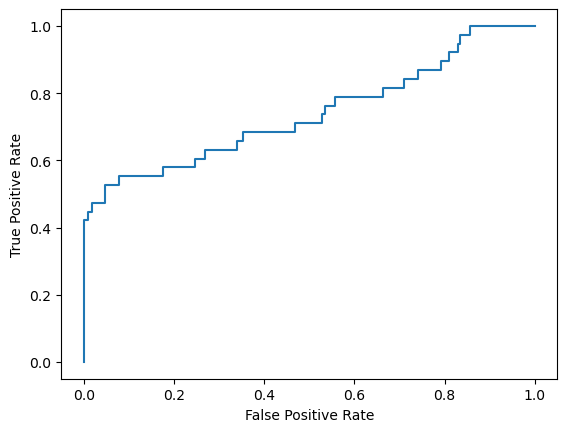

In [31]:
# model false positive
# model true positive
model_fpr, model_tpr, tresholds= roc_curve(y_test,grid_search.predict_proba(X_test)[:, 1])
plt.plot(model_fpr,model_tpr,label="ROC curve (area = %0.2f)" % model_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")